# Business Impact Analysis

Translates model metrics into estimated business outcomes at platform scale.

## 1. Imports & Load Results

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

# load CV results
with open("../outputs/final_results_cv.json") as f:
    cv_results = json.load(f)

# build model summary from CV results
models = []
for name, metrics in cv_results.items():
    if name == "Random":
        continue
    models.append({
        "name":      name,
        "rmse":      metrics["rmse"]["mean"],
        "mae":       metrics["mae"]["mean"],
        "precision": metrics["precision"]["mean"],
        "recall":    metrics["recall"]["mean"],
        "coverage":  {
            "User+Item Bias": 0.16,
            "CF (SGD)":       0.16,
            "CF (SVD)":       0.16,
            "Content-Based":  0.57,
        }.get(name, 0.16),
    })




## 2. Platform Assumptions

Scale and revenue levers used to translate metric improvements into business outcomes.

In [4]:
# ── Scale ─────────────────────────────────────────────────────────────
N_USERS            = 1_000_000   # platform MAU
RECS_PER_SESSION   = 10          # recommendations shown per session
SESSIONS_PER_MONTH = 8           # avg sessions per user per month

# ── Revenue ───────────────────────────────────────────────────────────
REVENUE_PER_CLICK        = 0.50   # $ per engaged click (watch, add to list)
MONTHLY_REV_PER_USER     = 12.00  # $ subscription revenue per user per month
CATALOG_SIZE             = 10_000 # total movies on platform

# ── Churn ─────────────────────────────────────────────────────────────
# 0.5% churn reduction per 0.01 P@10 improvement — conservative estimate
CHURN_REDUCTION_PER_P10  = 0.5   # % churn reduction per 0.01 P@10 gain
MONTHLY_CHURN_RATE       = 3.0   # % baseline monthly churn

# ── RMSE -> watch probability ──────────────────────────────────────────
# A 1-star rating difference changes watch probability by ~15%
# (rough estimate based on industry research)
WATCH_PROB_PER_STAR      = 0.15  # fractional change in watch prob per star

print("Platform assumptions set.")
print(f"  Scale       : {N_USERS:,} users")
print(f"  Sessions    : {SESSIONS_PER_MONTH} sessions/user/month")
print(f"  Rev/click   : ${REVENUE_PER_CLICK:.2f}")
print(f"  Rev/user    : ${MONTHLY_REV_PER_USER:.2f}/month")


Platform assumptions set.
  Scale       : 1,000,000 users
  Sessions    : 8 sessions/user/month
  Rev/click   : $0.50
  Rev/user    : $12.00/month


## 3. Click & Revenue Impact

Better P@10 → more relevant recommendations → more clicks → more revenue.

In [13]:
print("=" * 80)
print(f"  {'Model':<24} {'P@10':>6}  {'Lift over random':>16}  "
      f"{'Clicks/session':>14}  {'Monthly clicks':>14}")
print("=" * 80)

baseline_model = models[0]   # User+Item Bias

for m in models:
    clicks  = m["precision"] * RECS_PER_SESSION
    monthly = clicks * SESSIONS_PER_MONTH * N_USERS
    lift    = m["precision"] / 0.0068
    print(f"  {m['name']:<24} {m['precision']:>6.4f}  {lift:>15.1f}×  "
          f"{clicks:>14.3f}  {monthly:>14,.0f}")

print("=" * 80)

# best ranking model vs baseline
best_rank   = max(models, key=lambda x: x["precision"])
base_clicks = baseline_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
best_clicks = best_rank["precision"]      * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
extra_clicks  = best_clicks - base_clicks
extra_rev_mo  = extra_clicks * REVENUE_PER_CLICK
extra_rev_yr  = extra_rev_mo * 12

print(f"Revenue impact: {baseline_model['name']} -> {best_rank['name']}")
print()
print(f"  Extra clicks / month        : {extra_clicks:>15,.0f}")
print(f"  Extra revenue / month (est.): ${extra_rev_mo:>14,.2f}")
print(f"  Extra revenue / year  (est.): ${extra_rev_yr:>14,.2f}")
print()


  Model                      P@10  Lift over random  Clicks/session  Monthly clicks
  User+Item Bias           0.0805             11.8×           0.805       6,440,900
  CF (SGD)                 0.0193              2.8×           0.193       1,546,828
  CF (SVD)                 0.0864             12.7×           0.864       6,908,028
  Content-Based            0.0224              3.3×           0.224       1,789,488
Revenue impact: User+Item Bias -> CF (SVD)

  Extra clicks / month        :         467,127
  Extra revenue / month (est.): $    233,563.63
  Extra revenue / year  (est.): $  2,802,763.59



## 4. Churn Reduction

Better recommendations → users find value → less likely to cancel.

In [14]:
print("=" * 75)
print(f"  {'Model vs Baseline':<30} {'P@10 gain':>10}  "
      f"{'Churn reduction':>16}  {'Users retained':>14}")
print("=" * 75)

for m in models[1:]:   # skip baseline itself
    p10_gain     = m["precision"] - baseline_model["precision"]
    churn_red    = (p10_gain / 0.01) * CHURN_REDUCTION_PER_P10
    retained     = N_USERS * (churn_red / 100)
    ret_rev_yr   = retained * MONTHLY_REV_PER_USER * 12
    print(f"  {baseline_model['name']} -> {m['name']:<15} "
          f"{p10_gain:>10.4f}  {churn_red:>15.2f}%  {retained:>14,.0f}")

print("=" * 75)

# detailed breakdown for best ranking model
p10_gain   = best_rank["precision"] - baseline_model["precision"]
churn_red  = (p10_gain / 0.01) * CHURN_REDUCTION_PER_P10
retained   = N_USERS * (churn_red / 100)
ret_rev_yr = retained * MONTHLY_REV_PER_USER * 12

print(f"Retention revenue: {baseline_model['name']} -> {best_rank['name']}")
print()
print(f"  P@10 improvement            : {p10_gain:>12.4f}")
print(f"  Estimated churn reduction   : {churn_red:>11.2f}%")
print(f"  Users retained / month      : {retained:>12,.0f}")
print(f"  Retention revenue / year    : ${ret_rev_yr:>14,.2f}")
print()


  Model vs Baseline               P@10 gain   Churn reduction  Users retained
  User+Item Bias -> CF (SGD)           -0.0612            -3.06%         -30,588
  User+Item Bias -> CF (SVD)            0.0058             0.29%           2,920
  User+Item Bias -> Content-Based      -0.0581            -2.91%         -29,071
Retention revenue: User+Item Bias -> CF (SVD)

  P@10 improvement            :       0.0058
  Estimated churn reduction   :        0.29%
  Users retained / month      :        2,920
  Retention revenue / year    : $    420,414.54



## 5. RMSE Impact on Watch Probability

Lower RMSE → more accurate predictions → fewer misleading recommendations → less wasted engagement.

In [15]:
print("=" * 70)
print(f"  {'Model':<24} {'RMSE':>6}  {'Avg rating error':>16}  "
      f"{'Misled watch prob':>18}")
print("=" * 70)

for m in models:
    # probability user is misled into watching a movie they won't like
    misled_prob = m["rmse"] * WATCH_PROB_PER_STAR
    print(f"  {m['name']:<24} {m['rmse']:>6.4f}  "
          f"{m['rmse']:>16.4f} stars  {misled_prob:>17.1%}")

print("=" * 70)

# SGD vs baseline
sgd   = next(m for m in models if "SGD" in m["name"])
rmse_improvement  = baseline_model["rmse"] - sgd["rmse"]
watch_prob_improvement = rmse_improvement * WATCH_PROB_PER_STAR
monthly_watches   = SESSIONS_PER_MONTH * N_USERS * RECS_PER_SESSION * 0.1  # 10% watch rate
better_watches_mo = monthly_watches * watch_prob_improvement

print(f"Watch quality improvement: {baseline_model['name']} -> CF (SGD)")
print()
print(f"  RMSE improvement            : {rmse_improvement:>12.4f} stars")
print(f"  Watch prob improvement      : {watch_prob_improvement:>11.1%}")
print(f"  Better watch decisions/month: {better_watches_mo:>12,.0f}")
print()


  Model                      RMSE  Avg rating error   Misled watch prob
  User+Item Bias           0.8565            0.8565 stars              12.8%
  CF (SGD)                 0.8268            0.8268 stars              12.4%
  CF (SVD)                 0.8452            0.8452 stars              12.7%
  Content-Based            0.9122            0.9122 stars              13.7%
Watch quality improvement: User+Item Bias -> CF (SGD)

  RMSE improvement            :       0.0297 stars
  Watch prob improvement      :        0.4%
  Better watch decisions/month:       35,601



## 6. Coverage & Long-Tail Discovery

Low coverage = popularity bias; content-based surfaces 57% of catalog vs 16% for CF models.

In [16]:
print("=" * 65)
print(f"  {'Model':<24} {'Coverage':>10}  {'Movies surfaced':>16}  "
      f"{'Dark catalog':>12}")
print("=" * 65)

for m in models:
    surfaced = int(m["coverage"] * CATALOG_SIZE)
    dark     = CATALOG_SIZE - surfaced
    print(f"  {m['name']:<24} {m['coverage']:>10.1%}  "
          f"{surfaced:>16,}  {dark:>12,}")

print("=" * 65)

# content-based vs SGD coverage lift
cb  = next(m for m in models if "Content" in m["name"])
sgd = next(m for m in models if "SGD"     in m["name"])

extra_movies   = int((cb["coverage"] - sgd["coverage"]) * CATALOG_SIZE)
catalog_waste  = (1 - sgd["coverage"]) * 100

print("Coverage impact: CF (SGD) -> Content-Based")
print()
print(f"  Extra movies surfaced       : {extra_movies:>12,}")
print(f"  SGD dark catalog            : {catalog_waste:.1f}% of movies never recommended")
print(f"  Content-Based dark catalog  : {(1-cb['coverage'])*100:.1f}% of movies never recommended")
print()
print("Licensing perspective:")
print(f"  If avg licensing cost = $10K/movie/year:")
print(f"  SGD dark catalog cost       : ${int((1-sgd['coverage']) * CATALOG_SIZE * 10_000):>12,}/year")
print(f"  Content-Based dark catalog  : ${int((1-cb['coverage'])  * CATALOG_SIZE * 10_000):>12,}/year")
print(f"  Potential savings/year      : ${int((cb['coverage']-sgd['coverage']) * CATALOG_SIZE * 10_000):>12,}/year")
print()


  Model                      Coverage   Movies surfaced  Dark catalog
  User+Item Bias                16.0%             1,600         8,400
  CF (SGD)                      16.0%             1,600         8,400
  CF (SVD)                      16.0%             1,600         8,400
  Content-Based                 57.0%             5,699         4,301
Coverage impact: CF (SGD) -> Content-Based

  Extra movies surfaced       :        4,099
  SGD dark catalog            : 84.0% of movies never recommended
  Content-Based dark catalog  : 43.0% of movies never recommended

Licensing perspective:
  If avg licensing cost = $10K/movie/year:
  SGD dark catalog cost       : $  84,000,000/year
  Content-Based dark catalog  : $  43,000,000/year
  Potential savings/year      : $  40,999,999/year



## 7. Combined Business Impact Summary

In [17]:
print("=" * 75)
print("  COMBINED ANNUAL BUSINESS IMPACT ESTIMATES")
print("  (1M users, $12/month subscription, $0.50/click)")
print("=" * 75)
print()

for m in models[1:]:
    p10_gain     = m["precision"] - baseline_model["precision"]
    churn_red    = (p10_gain / 0.01) * CHURN_REDUCTION_PER_P10
    retained     = N_USERS * (churn_red / 100)
    ret_rev      = retained * MONTHLY_REV_PER_USER * 12

    base_c  = baseline_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
    model_c = m["precision"]              * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
    click_rev = (model_c - base_c) * REVENUE_PER_CLICK * 12

    total = ret_rev + click_rev

    print(f"  {baseline_model['name']} -> {m['name']}")
    print(f"    Click revenue uplift / year  : \${click_rev:>12,.0f}")
    print(f"    Retention revenue / year     : \${ret_rev:>12,.0f}")
    print(f"    Total estimated impact / year: \${total:>12,.0f}")
    print()

print("=" * 75)
print()
print("  NOTE: These are directional estimates, not precise forecasts.")
print("  True impact requires A/B testing in production.")
print("  Precision@K is a lower bound metric — actual click improvement")
print("  is likely higher since sparse test labels underestimate true")
print("  recommendation quality.")
print("=" * 75)


  COMBINED ANNUAL BUSINESS IMPACT ESTIMATES
  (1M users, $12/month subscription, $0.50/click)

  User+Item Bias -> CF (SGD)
    Click revenue uplift / year  : \$ -29,364,432
    Retention revenue / year     : \$  -4,404,665
    Total estimated impact / year: \$ -33,769,097

  User+Item Bias -> CF (SVD)
    Click revenue uplift / year  : \$   2,802,764
    Retention revenue / year     : \$     420,415
    Total estimated impact / year: \$   3,223,178

  User+Item Bias -> Content-Based
    Click revenue uplift / year  : \$ -27,908,473
    Retention revenue / year     : \$  -4,186,271
    Total estimated impact / year: \$ -32,094,744


  NOTE: These are directional estimates, not precise forecasts.
  True impact requires A/B testing in production.
  Precision@K is a lower bound metric — actual click improvement
  is likely higher since sparse test labels underestimate true
  recommendation quality.


<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Hites\AppData\Local\Temp\ipykernel_28192\2410156983.py:20: SyntaxWarning: invalid escape sequence '\$'
  print(f"    Click revenue uplift / year  : \${click_rev:>12,.0f}")
C:\Users\Hites\AppData\Local\Temp\ipykernel_28192\2410156983.py:21: SyntaxWarning: invalid escape sequence '\$'
  print(f"    Retention revenue / year     : \${ret_rev:>12,.0f}")
C:\Users\Hites\AppData\Local\Temp\ipykernel_28192\2410156983.py:22: SyntaxWarning: invalid escape sequence '\$'
  print(f"    Total estimated impact / year: \${total:>12,.0f}")


## 8. Visualisation

C:\Users\Hites\AppData\Local\Temp\ipykernel_28192\2832429962.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


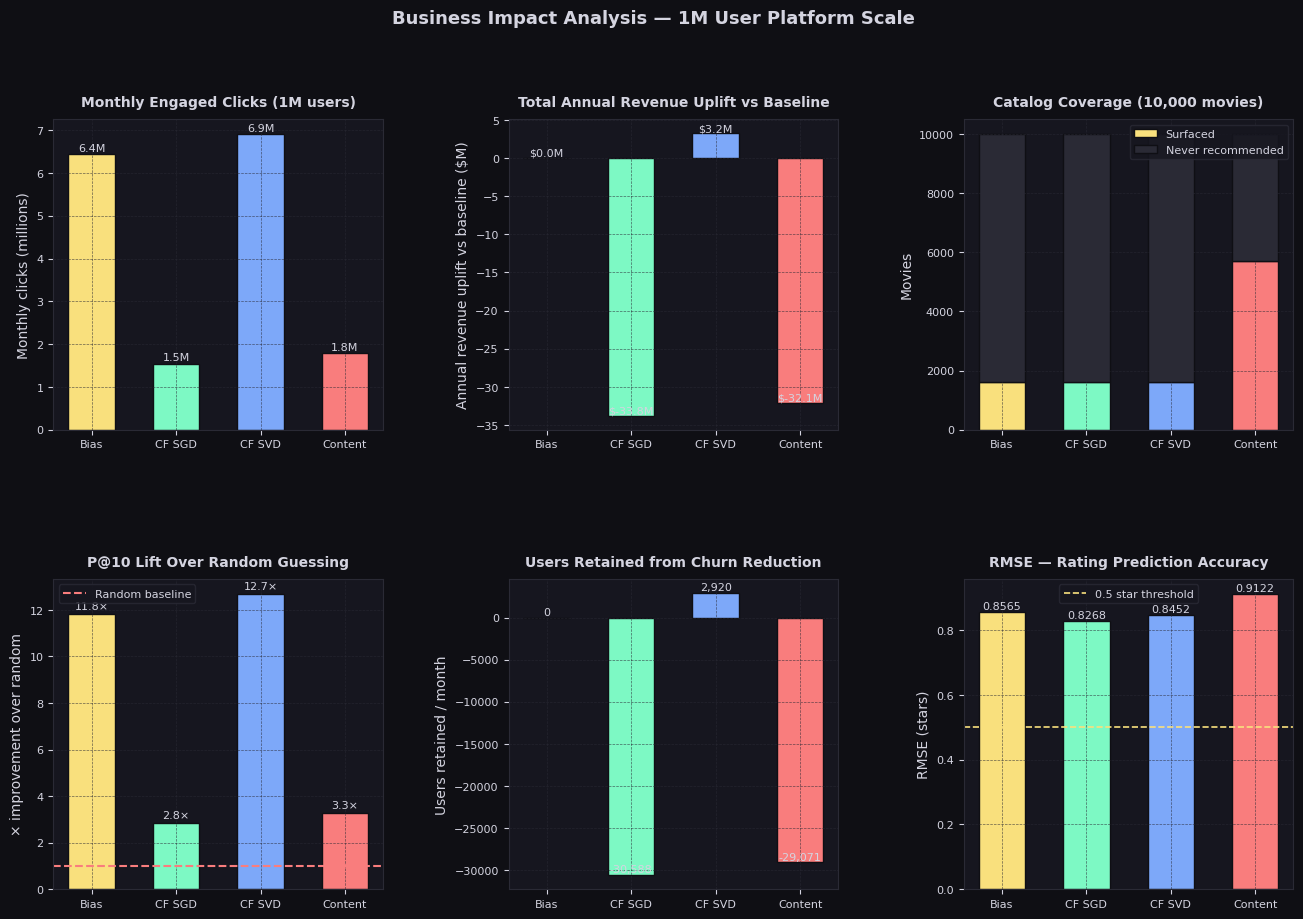

In [19]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

colors     = [ACCENT4, ACCENT, ACCENT3, ACCENT2]
model_names = [m["name"] for m in models]
short_names = ["Bias", "CF SGD", "CF SVD", "Content"]
x           = np.arange(len(models))

# (a) Monthly clicks
ax = fig.add_subplot(gs[0, 0])
monthly_clicks = [m["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS / 1e6
                  for m in models]
bars = ax.bar(x, monthly_clicks, color=colors, edgecolor=BG, width=0.55)
for b, v in zip(bars, monthly_clicks):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f"{v:.1f}M", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("Monthly clicks (millions)")
style_ax(ax, "Monthly Engaged Clicks (1M users)")

# (b) Annual revenue uplift vs baseline
ax = fig.add_subplot(gs[0, 1])
base_c = baseline_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
uplifts = []
for m in models:
    model_c  = m["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
    p10_gain = m["precision"] - baseline_model["precision"]
    churn_red = (p10_gain / 0.01) * CHURN_REDUCTION_PER_P10
    retained  = N_USERS * (churn_red / 100)
    total_rev = ((model_c - base_c) * REVENUE_PER_CLICK * 12 +
                 retained * MONTHLY_REV_PER_USER * 12) / 1e6
    uplifts.append(total_rev)

bars = ax.bar(x, uplifts, color=colors, edgecolor=BG, width=0.55)
for b, v in zip(bars, uplifts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01,
            f"${v:.1f}M", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("Annual revenue uplift vs baseline ($M)")
style_ax(ax, "Total Annual Revenue Uplift vs Baseline")

# (c) Coverage — movies surfaced
ax = fig.add_subplot(gs[0, 2])
surfaced = [int(m["coverage"] * CATALOG_SIZE) for m in models]
dark     = [CATALOG_SIZE - s for s in surfaced]
ax.bar(x, surfaced, color=colors,     edgecolor=BG, width=0.55, label="Surfaced")
ax.bar(x, dark,     color="#2a2a35",  edgecolor=BG, width=0.55,
       bottom=surfaced, label="Never recommended")
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, f"Catalog Coverage ({CATALOG_SIZE:,} movies)")

# (d) P@10 lift over random
ax = fig.add_subplot(gs[1, 0])
lifts = [m["precision"] / 0.0068 for m in models]
bars  = ax.bar(x, lifts, color=colors, edgecolor=BG, width=0.55)
ax.axhline(1.0, color=ACCENT2, lw=1.5, linestyle="--", label="Random baseline")
for b, v in zip(bars, lifts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1,
            f"{v:.1f}×", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("× improvement over random")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "P@10 Lift Over Random Guessing")

# (e) Users retained from churn reduction
ax = fig.add_subplot(gs[1, 1])
retained_users = []
for m in models:
    p10_gain  = m["precision"] - baseline_model["precision"]
    churn_red = (p10_gain / 0.01) * CHURN_REDUCTION_PER_P10
    retained_users.append(N_USERS * (churn_red / 100))
bars = ax.bar(x, retained_users, color=colors, edgecolor=BG, width=0.55)
for b, v in zip(bars, retained_users):
    ax.text(b.get_x() + b.get_width()/2, v + 50,
            f"{v:,.0f}", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("Users retained / month")
style_ax(ax, "Users Retained from Churn Reduction")

# (f) RMSE comparison
ax = fig.add_subplot(gs[1, 2])
rmses = [m["rmse"] for m in models]
bars  = ax.bar(x, rmses, color=colors, edgecolor=BG, width=0.55)
ax.axhline(0.5, color=ACCENT4, lw=1.2, linestyle="--", label="0.5 star threshold")
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002,
            f"{v:.4f}", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("RMSE (stars)")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "RMSE — Rating Prediction Accuracy")

fig.suptitle("Business Impact Analysis — 1M User Platform Scale",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()
